<a href="https://colab.research.google.com/github/Jorgellamocca/WeatherNext3_Peru/blob/main/WeatherNext_v1.1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# ============================================================
# 1. LIBRERÍAS
# ============================================================

import ee
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from datetime import timedelta
from google.colab import files

# Estilo general
plt.rcParams.update({
    "figure.figsize": (14, 6),
    "font.size": 11,
    "axes.titlesize": 15,
    "axes.labelsize": 12,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "legend.frameon": False
})


In [2]:
# ============================================================
# 2. CONFIGURACIÓN
# ============================================================

PROJECT_ID = "gee-proyecto-peru-494007"

ASSET = (
    "projects/gcp-public-data-weathernext/assets/"
    "weathernext_3_0_0_0p1deg"
)

# Piura
LAT_PIURA = -5.19
LON_PIURA = -80.63

# Resolución nativa del producto
SCALE = 11132

# Zona horaria de Perú
UTC_OFFSET_HOURS = -5

In [3]:
# ============================================================
# 3. INICIALIZAR EARTH ENGINE
# ============================================================

ee.Initialize(project=PROJECT_ID)

print("Earth Engine inicializado correctamente.")

Earth Engine inicializado correctamente.


*** Earth Engine *** Share your feedback by taking our Annual Developer Satisfaction Survey: https://google.qualtrics.com/jfe/form/SV_9oS0DRcPvElRMNw?source=python


In [4]:
# ============================================================
# 4. CARGAR WEATHERNEXT 3
# ============================================================

dataset = ee.ImageCollection(ASSET)

print("Colección cargada:")
print(ASSET)

Colección cargada:
projects/gcp-public-data-weathernext/assets/weathernext_3_0_0_0p1deg


In [5]:
# ============================================================
# 5. PUNTO DE PIURA
# ============================================================

punto_piura = ee.Geometry.Point([
    LON_PIURA,
    LAT_PIURA
])

In [6]:
# ============================================================
# 6. IDENTIFICAR LA ÚLTIMA CORRIDA PRINCIPAL DE 15 DÍAS
#
# Las corridas principales:
#   00 UTC
#   06 UTC
#   12 UTC
#   18 UTC
#
# Tienen 360 horas.
#
# Buscamos directamente las imágenes con forecast_hour = 360
# y obtenemos el último start_time disponible.
# ============================================================

corridas_15d = dataset.filter(
    ee.Filter.eq("forecast_hour", 360)
)

starts_15d = (
    corridas_15d
    .aggregate_array("start_time")
    .distinct()
    .sort()
)

ultimo_start_time = (
    starts_15d
    .get(starts_15d.size().subtract(1))
    .getInfo()
)

print("\n==============================================")
print("ÚLTIMA CORRIDA PRINCIPAL DE 15 DÍAS")
print("==============================================")
print("Start time:", ultimo_start_time)



ÚLTIMA CORRIDA PRINCIPAL DE 15 DÍAS
Start time: 2026-09-21T06:00:00Z


In [7]:
# ============================================================
# 7. EXTRAER LA CORRIDA COMPLETA
# ============================================================

corrida = dataset.filter(
    ee.Filter.eq(
        "start_time",
        ultimo_start_time
    )
)

numero_imagenes = corrida.size().getInfo()

forecast_hours = (
    corrida
    .aggregate_array("forecast_hour")
    .distinct()
    .sort()
    .getInfo()
)

print("Número de horas:", numero_imagenes)
print("Primer forecast_hour:", min(forecast_hours))
print("Último forecast_hour:", max(forecast_hours))


Número de horas: 360
Primer forecast_hour: 1
Último forecast_hour: 360


In [8]:
# ============================================================
# 8. BANDAS
# ============================================================

bands = [

    # Temperatura
    "temperature_2m_mean",
    "temperature_2m_p10",
    "temperature_2m_p25",
    "temperature_2m_p50",
    "temperature_2m_p75",
    "temperature_2m_p90",

    # Precipitación
    "total_precipitation_1hr_mean",
    "total_precipitation_1hr_p10",
    "total_precipitation_1hr_p25",
    "total_precipitation_1hr_p50",
    "total_precipitation_1hr_p75",
    "total_precipitation_1hr_p90"
]

corrida = corrida.select(bands)

In [9]:
# ============================================================
# 9. FUNCIÓN DE EXTRACCIÓN
# ============================================================

def extraer_punto(img):

    valores = img.reduceRegion(
        reducer=ee.Reducer.first(),
        geometry=punto_piura,
        scale=SCALE,
        bestEffort=True
    )

    propiedades = {
        "forecast_hour": img.get("forecast_hour"),
        "start_time": img.get("start_time"),
        "end_time": img.get("end_time")
    }

    valores = valores.combine(
        propiedades,
        overwrite=True
    )

    return ee.Feature(
        None,
        valores
    )

In [10]:
# ============================================================
# 10. EXTRAER TODA LA CORRIDA
# ============================================================

print("\nExtrayendo información para Piura...")

fc = ee.FeatureCollection(
    corrida.map(extraer_punto)
)

resultado = fc.getInfo()

df = pd.DataFrame([
    f["properties"]
    for f in resultado["features"]
])


Extrayendo información para Piura...


In [11]:
# ============================================================
# 11. ORDENAR
# ============================================================

df = df.sort_values(
    "forecast_hour"
).reset_index(drop=True)

In [12]:
# ============================================================
# 12. CONVERTIR FECHAS
# ============================================================

df["start_time"] = pd.to_datetime(
    df["start_time"],
    utc=True
)

df["end_time"] = pd.to_datetime(
    df["end_time"],
    utc=True
)

In [13]:
# ============================================================
# 13. CONVERTIR TEMPERATURA
#
# WeatherNext:
# temperatura = Kelvin
#
# Celsius = Kelvin - 273.15
# ============================================================

temp_cols = [
    "temperature_2m_mean",
    "temperature_2m_p10",
    "temperature_2m_p25",
    "temperature_2m_p50",
    "temperature_2m_p75",
    "temperature_2m_p90"
]

for col in temp_cols:

    df[col.replace(
        "temperature_2m",
        "temp_C"
    )] = df[col] - 273.15

In [14]:
# ============================================================
# 14. CONVERTIR PRECIPITACIÓN
#
# WeatherNext:
# precipitación = metros
#
# 1 m = 1000 mm
# ============================================================

precip_cols = [
    "total_precipitation_1hr_mean",
    "total_precipitation_1hr_p10",
    "total_precipitation_1hr_p25",
    "total_precipitation_1hr_p50",
    "total_precipitation_1hr_p75",
    "total_precipitation_1hr_p90"
]

for col in precip_cols:

    df[col.replace(
        "total_precipitation_1hr_",
        "precip_mm_"
    )] = df[col] * 1000

In [15]:
# ============================================================
# 15. FECHA LOCAL DE PERÚ
#
# Earth Engine entrega UTC.
#
# Perú = UTC-5
#
# Esto es MUY importante para comparar posteriormente
# contra estaciones SENAMHI/PISCO.
# ============================================================

df["fecha_local"] = (
    df["end_time"]
    + pd.Timedelta(hours=UTC_OFFSET_HOURS)
).dt.floor("D")

In [16]:
# ============================================================
# 16. MOSTRAR DATOS HORARIOS
# ============================================================

print("\n==============================================")
print("DATOS HORARIOS")
print("==============================================")

print(
    df[
        [
            "forecast_hour",
            "end_time",
            "fecha_local",
            "temp_C_mean",
            "temp_C_p10",
            "temp_C_p50",
            "temp_C_p90",
            "precip_mm_mean",
            "precip_mm_p50"
        ]
    ].head(10)
)


DATOS HORARIOS
   forecast_hour                  end_time               fecha_local  \
0              1 2026-09-21 07:00:00+00:00 2026-09-21 00:00:00+00:00   
1              2 2026-09-21 08:00:00+00:00 2026-09-21 00:00:00+00:00   
2              3 2026-09-21 09:00:00+00:00 2026-09-21 00:00:00+00:00   
3              4 2026-09-21 10:00:00+00:00 2026-09-21 00:00:00+00:00   
4              5 2026-09-21 11:00:00+00:00 2026-09-21 00:00:00+00:00   
5              6 2026-09-21 12:00:00+00:00 2026-09-21 00:00:00+00:00   
6              7 2026-09-21 13:00:00+00:00 2026-09-21 00:00:00+00:00   
7              8 2026-09-21 14:00:00+00:00 2026-09-21 00:00:00+00:00   
8              9 2026-09-21 15:00:00+00:00 2026-09-21 00:00:00+00:00   
9             10 2026-09-21 16:00:00+00:00 2026-09-21 00:00:00+00:00   

   temp_C_mean  temp_C_p10  temp_C_p50  temp_C_p90  precip_mm_mean  \
0    23.466547   23.327814   23.473138   23.595941        0.010045   
1    23.410150   23.220331   23.426538   23.605798 

In [17]:
# ============================================================
# 17. TEMPERATURA DIARIA
#
# Tmedia = promedio de horas
# Tmin   = mínimo horario
# Tmax   = máximo horario
#
# Se conserva además la información del ensamble.
# ============================================================

daily_temp = (
    df
    .groupby("fecha_local")
    .agg(

        # Temperatura media del ensamble
        tmedia_C=(
            "temp_C_mean",
            "mean"
        ),

        # Incertidumbre de la temperatura media
        tmedia_p10_C=(
            "temp_C_p10",
            "mean"
        ),

        tmedia_p25_C=(
            "temp_C_p25",
            "mean"
        ),

        tmedia_p50_C=(
            "temp_C_p50",
            "mean"
        ),

        tmedia_p75_C=(
            "temp_C_p75",
            "mean"
        ),

        tmedia_p90_C=(
            "temp_C_p90",
            "mean"
        ),

        # Tmin de la trayectoria media
        tmin_C=(
            "temp_C_mean",
            "min"
        ),

        # Tmax de la trayectoria media
        tmax_C=(
            "temp_C_mean",
            "max"
        ),

        horas=(
            "forecast_hour",
            "count"
        )
    )
    .reset_index()
)


In [18]:
# ============================================================
# 18. PRECIPITACIÓN DIARIA
#
# Para precipitación se SUMAN las acumulaciones horarias.
#
# IMPORTANTE:
# La suma de P10/P90 horarios NO equivale matemáticamente
# al P10/P90 exacto de la precipitación diaria del ensamble.
#
# Por eso se denominan:
#   "rango agregado de incertidumbre horaria".
# ============================================================

daily_precip = (
    df
    .groupby("fecha_local")
    .agg(

        precip_mean_mm=(
            "precip_mm_mean",
            "sum"
        ),

        precip_p10_agregado_mm=(
            "precip_mm_p10",
            "sum"
        ),

        precip_p25_agregado_mm=(
            "precip_mm_p25",
            "sum"
        ),

        precip_p50_mm=(
            "precip_mm_p50",
            "sum"
        ),

        precip_p75_agregado_mm=(
            "precip_mm_p75",
            "sum"
        ),

        precip_p90_agregado_mm=(
            "precip_mm_p90",
            "sum"
        ),

        horas=(
            "forecast_hour",
            "count"
        )
    )
    .reset_index()
)


In [19]:
# ============================================================
# 19. UNIR TEMPERATURA + PRECIPITACIÓN
# ============================================================

daily = pd.merge(
    daily_temp,
    daily_precip,
    on=[
        "fecha_local",
        "horas"
    ],
    how="inner"
)


In [20]:
# ============================================================
# 20. CONSERVAR SOLO DÍAS COMPLETOS
#
# Esto elimina automáticamente el primer/último día
# si tienen menos de 24 horas.
# ============================================================

daily_full = daily[
    daily["horas"] == 24
].copy()


daily_full = daily_full.reset_index(
    drop=True
)

In [21]:
# ============================================================
# 21. INFORMACIÓN DEL PRONÓSTICO
# ============================================================

print("\n==============================================")
print("RESUMEN DEL PRONÓSTICO")
print("==============================================")

print(
    "Corrida:",
    ultimo_start_time
)

print(
    "Días completos:",
    len(daily_full)
)

if len(daily_full) > 0:

    print(
        "Primer día:",
        daily_full["fecha_local"].min().date()
    )

    print(
        "Último día:",
        daily_full["fecha_local"].max().date()
    )


RESUMEN DEL PRONÓSTICO
Corrida: 2026-09-21T06:00:00Z
Días completos: 14
Primer día: 2026-09-22
Último día: 2026-10-05


In [22]:
# ============================================================
# 22. TABLA FINAL
# ============================================================

print("\n==============================================")
print("PRONÓSTICO DIARIO")
print("==============================================")

print(
    daily_full[
        [
            "fecha_local",

            "tmedia_C",
            "tmedia_p25_C",
            "tmedia_p75_C",
            "tmedia_p10_C",
            "tmedia_p90_C",

            "tmin_C",
            "tmax_C",

            "precip_mean_mm",
            "precip_p50_mm",
            "precip_p25_agregado_mm",
            "precip_p75_agregado_mm",
            "precip_p10_agregado_mm",
            "precip_p90_agregado_mm"
        ]
    ].round(2).to_string(index=False)
)


PRONÓSTICO DIARIO
              fecha_local  tmedia_C  tmedia_p25_C  tmedia_p75_C  tmedia_p10_C  tmedia_p90_C  tmin_C  tmax_C  precip_mean_mm  precip_p50_mm  precip_p25_agregado_mm  precip_p75_agregado_mm  precip_p10_agregado_mm  precip_p90_agregado_mm
2026-09-22 00:00:00+00:00     26.84         26.42         27.27         26.05         27.62   22.32   33.73            1.17           0.15                    0.01                    0.97                     0.0                    2.91
2026-09-23 00:00:00+00:00     27.04         26.60         27.54         26.10         27.95   22.41   33.09            1.58           0.12                    0.01                    0.82                     0.0                    3.77
2026-09-24 00:00:00+00:00     27.45         26.99         27.87         26.61         28.31   22.16   34.99            0.18           0.00                    0.00                    0.01                     0.0                    0.08
2026-09-25 00:00:00+00:00     27.16      

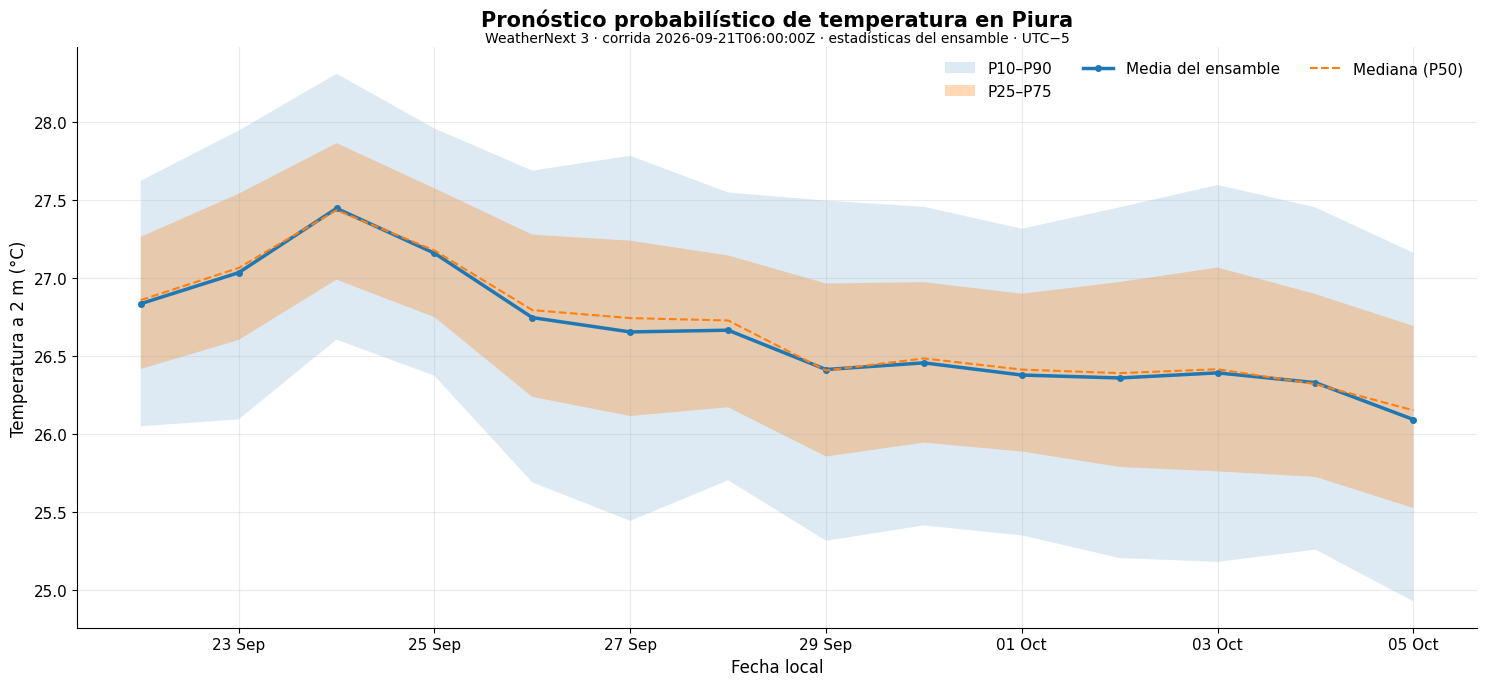

In [27]:
# ============================================================
# 23. GRÁFICA 1
# TEMPERATURA DIARIA
#
# Diseño:
#
#       P90 ────────────────
#             ╔══════════╗
#       P75   ║          ║
#             ║  P25-P75 ║
#       P25   ║          ║
#             ╚══════════╝
#       P10 ────────────────
#
# Línea azul = media del ensamble
#
# Tmin/Tmax se muestran como líneas punteadas.
# ============================================================

fig, ax = plt.subplots(
    figsize=(15, 7)
)

fechas = daily_full["fecha_local"]

# Banda P10-P90
ax.fill_between(
    fechas,
    daily_full["tmedia_p10_C"],
    daily_full["tmedia_p90_C"],
    alpha=0.15,
    label="P10–P90"
)

# Banda P25-P75
ax.fill_between(
    fechas,
    daily_full["tmedia_p25_C"],
    daily_full["tmedia_p75_C"],
    alpha=0.30,
    label="P25–P75"
)

# Media
ax.plot(
    fechas,
    daily_full["tmedia_C"],
    linewidth=2.5,
    marker="o",
    markersize=4,
    label="Media del ensamble"
)

# Mediana
ax.plot(
    fechas,
    daily_full["tmedia_p50_C"],
    linewidth=1.5,
    linestyle="--",
    label="Mediana (P50)"
)

# Tmin
#ax.plot(
#    fechas,
#   daily_full["tmin_C"],
#   linewidth=1.3,
#    label="Tmin"
#)

# Tmax
#ax.plot(
#   fechas,
 #   daily_full["tmax_C"],
#    linewidth=1.3,
#   label="Tmax"
#)

ax.set_title(
    "Pronóstico probabilístico de temperatura en Piura",
    pad=15,
    fontweight="bold"
)

ax.text(
    0.5,
    1.01,
    f"WeatherNext 3 · corrida {ultimo_start_time} · "
    "estadísticas del ensamble · UTC−5",
    transform=ax.transAxes,
    ha="center",
    fontsize=10
)

ax.set_ylabel(
    "Temperatura a 2 m (°C)"
)

ax.set_xlabel(
    "Fecha local"
)

ax.xaxis.set_major_locator(
    mdates.DayLocator(interval=2)
)

ax.xaxis.set_major_formatter(
    mdates.DateFormatter("%d %b")
)

plt.xticks(rotation=0)

ax.legend(
    loc="best",
    ncol=3
)

ax.grid(
    axis="y",
    alpha=0.25
)

plt.tight_layout()

plt.show()



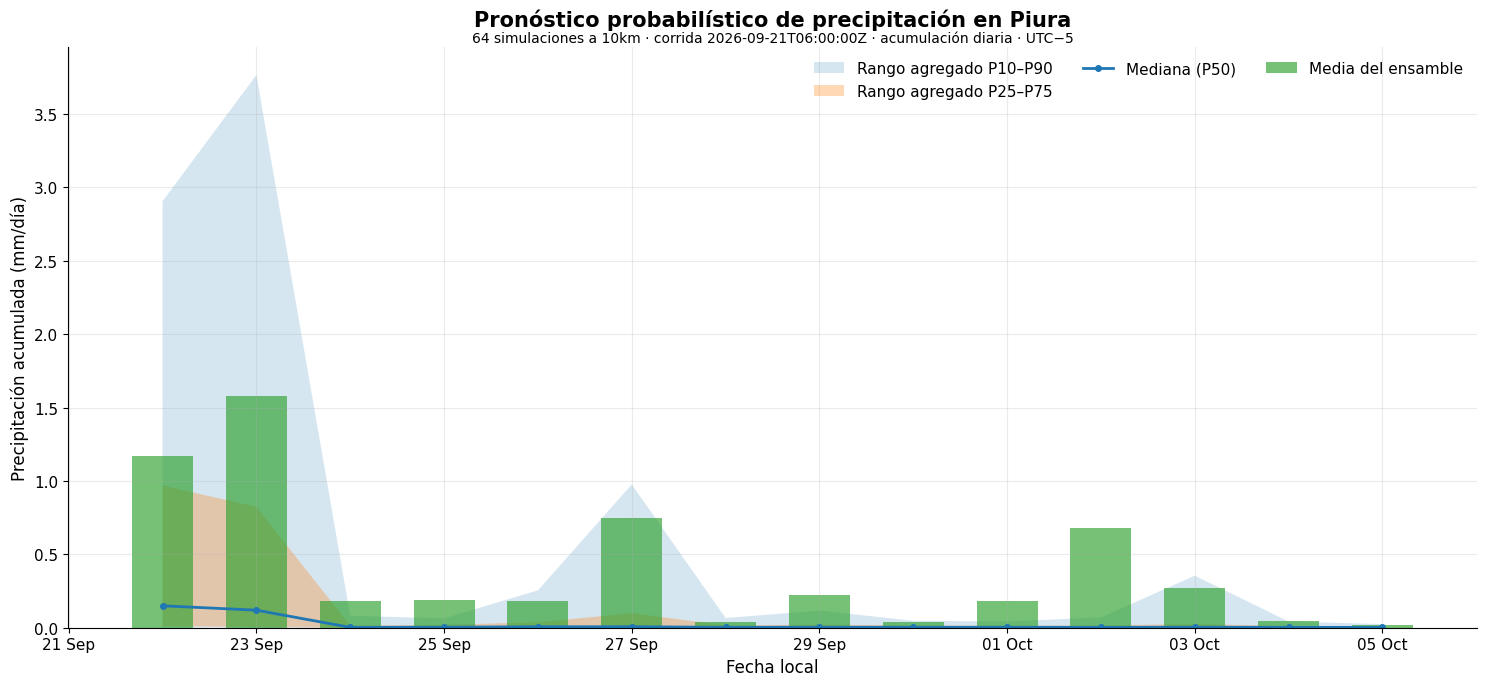

In [26]:
# ============================================================
# 24. GRÁFICA 2
# PRECIPITACIÓN DIARIA
#
# Barras = media del ensamble
#
# Línea = P50
#
# Banda = rango agregado P10-P90
# ============================================================

fig, ax = plt.subplots(
    figsize=(15, 7)
)

fechas = daily_full["fecha_local"]

# Banda de incertidumbre
ax.fill_between(
    fechas,
    daily_full["precip_p10_agregado_mm"],
    daily_full["precip_p90_agregado_mm"],
    alpha=0.18,
    label="Rango agregado P10–P90"
)

# Banda central
ax.fill_between(
    fechas,
    daily_full["precip_p25_agregado_mm"],
    daily_full["precip_p75_agregado_mm"],
    alpha=0.30,
    label="Rango agregado P25–P75"
)

# Barras de precipitación media
ax.bar(
    fechas,
    daily_full["precip_mean_mm"],
    width=0.65,
    alpha=0.65,
    label="Media del ensamble"
)

# Mediana
ax.plot(
    fechas,
    daily_full["precip_p50_mm"],
    linewidth=2,
    marker="o",
    markersize=4,
    label="Mediana (P50)"
)

ax.set_title(
    "Pronóstico probabilístico de precipitación en Piura",
    pad=15,
    fontweight="bold"
)

ax.text(
    0.5,
    1.01,
    f"64 simulaciones a 10km · corrida {ultimo_start_time} · "
    "acumulación diaria · UTC−5",
    transform=ax.transAxes,
    ha="center",
    fontsize=10
)

ax.set_ylabel(
    "Precipitación acumulada (mm/día)"
)

ax.set_xlabel(
    "Fecha local"
)

ax.xaxis.set_major_locator(
    mdates.DayLocator(interval=2)
)

ax.xaxis.set_major_formatter(
    mdates.DateFormatter("%d %b")
)

plt.xticks(rotation=0)

ax.legend(
    loc="best",
    ncol=3
)

ax.grid(
    axis="y",
    alpha=0.25
)

plt.tight_layout()

plt.show()



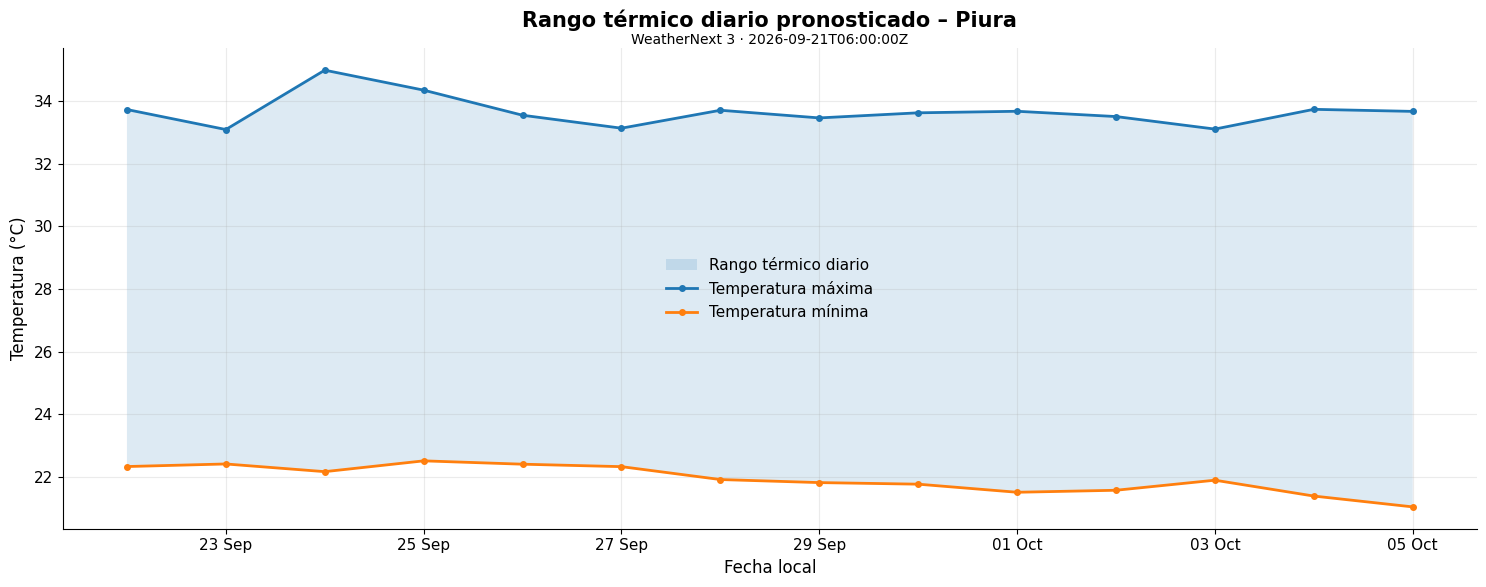

In [25]:
# ============================================================
# 25. GRÁFICA 3
# TEMPERATURA MÁXIMA Y MÍNIMA
#
# Esta gráfica comunica mejor al público la amplitud
# térmica esperada.
# ============================================================

fig, ax = plt.subplots(
    figsize=(15, 6)
)

ax.fill_between(
    fechas,
    daily_full["tmin_C"],
    daily_full["tmax_C"],
    alpha=0.15,
    label="Rango térmico diario"
)

ax.plot(
    fechas,
    daily_full["tmax_C"],
    linewidth=2,
    marker="o",
    markersize=4,
    label="Temperatura máxima"
)

ax.plot(
    fechas,
    daily_full["tmin_C"],
    linewidth=2,
    marker="o",
    markersize=4,
    label="Temperatura mínima"
)

ax.set_title(
    "Rango térmico diario pronosticado – Piura",
    fontweight="bold",
    pad=15
)

ax.text(
    0.5,
    1.01,
    f"WeatherNext 3 · {ultimo_start_time}",
    transform=ax.transAxes,
    ha="center",
    fontsize=10
)

ax.set_ylabel(
    "Temperatura (°C)"
)

ax.set_xlabel(
    "Fecha local"
)

ax.xaxis.set_major_locator(
    mdates.DayLocator(interval=2)
)

ax.xaxis.set_major_formatter(
    mdates.DateFormatter("%d %b")
)

ax.legend(
    loc="best"
)

ax.grid(
    axis="y",
    alpha=0.25
)

plt.tight_layout()

plt.show()

